<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Fundamentos del Aprendizaje Supervisado 🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 01
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/01%20-%20Modelos%20Lineales%20Supervisados/00_Fundamentos_del_Aprendizaje_Supervisado.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno abre el Módulo 01 y desarrolla la **Sección 1.7 (Supervised Learning)** del Capítulo 1. Es el marco teórico sobre el que se apoyan **todos** los modelos supervisados del curso, empezando por la regresión lineal y la regresión logística de los dos cuadernos siguientes.

Al terminar podrás:

1. **Formalizar** el aprendizaje supervisado con la notación $(X, y, f, \mathcal{H}, L)$ y distinguir **riesgo verdadero** de **riesgo empírico**.
2. **Reconocer** la regresión y la clasificación como dos casos del *mismo* marco, que difieren en el tipo de $y$ y en la función de pérdida.
3. **Particionar** los datos en entrenamiento, validación y prueba, y explicar qué pregunta responde cada conjunto.
4. **Diagnosticar** subajuste y sobreajuste con curvas de aprendizaje y de validación.
5. **Estimar numéricamente** la descomposición sesgo–varianza con una simulación Monte Carlo y observar cómo cambia con la complejidad del modelo.
6. **Explicar** por qué la regularización controla la complejidad y qué dice el teorema *No Free Lunch*.

> 📍 **Dónde estamos:** Módulo 01, cuaderno 0 de 2 (antes de [Regresión Lineal](01_Regresion_Lineal.ipynb)). Se apoya en el [paradigma supervisado del Módulo 00](../00%20-%20Introduccion%20al%20Machine%20Learning/01_Paradigmas_de_Aprendizaje.ipynb).

> 🔗 **Para no repetir:** la validación cruzada, la partición estratificada y una primera mirada al dilema sesgo–varianza ya se trabajan en [Data Mining — Módulo 02 (Fundamentos del Aprendizaje Supervisado)](../../Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/00_Fundamentos_del_Aprendizaje_Supervisado.ipynb) y en [Data Science Programming — Módulo 07](../../Data%20Science%20programming/07%20-%20Regression/02_Consideraciones_Regresion_Multiple.ipynb). Aquí vamos **más profundo**: formulación formal, derivación y estimación numérica de la descomposición.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 1 (*Main Challenges of Machine Learning*: sobreajuste, subajuste, conjuntos de validación y prueba) y Cap. 4 (*Training Models*, sección *Learning Curves*) (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt). Cap. 6 (*Learning Best Practices for Model Evaluation and Hyperparameter Tuning*), secciones *Diagnosing bias and variance problems with learning curves* y *Addressing overfitting and underfitting with validation curves* (disponible en `Machine Learning/Libros/`).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman** (2.ª ed., Springer). Cap. 2 (*Overview of Supervised Learning*) y Cap. 7 (*Model Assessment and Selection*), sección 7.3 *The Bias–Variance Decomposition*.
- *An Introduction to Statistical Learning* — **James, Witten, Hastie & Tibshirani** (Springer; acceso libre en la web de los autores). Cap. 2 (*Statistical Learning*).
- *Statistical Learning Theory* — **Vladimir N. Vapnik** (Wiley, 1998). Origen formal del principio de **minimización del riesgo empírico**.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Cross-validation and model evaluation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [scikit-learn: Validation curves y learning curves](https://scikit-learn.org/stable/modules/learning_curve.html)
- [scikit-learn: Underfitting vs. Overfitting (ejemplo)](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)

---
## 1. Formulación del Aprendizaje Supervisado 📐

En el aprendizaje supervisado disponemos de un conjunto de **$n$ ejemplos etiquetados**

$$\mathcal{D} = \{(\mathbf{x}_1, y_1), \ldots, (\mathbf{x}_n, y_n)\}, \qquad \mathbf{x}_i \in \mathcal{X} \subseteq \mathbb{R}^p, \quad y_i \in \mathcal{Y},$$

donde $\mathbf{x}_i$ es el **vector de características** (*features*) del ejemplo $i$ y $y_i$ su **etiqueta** (*target*). Se asume que los pares provienen de una distribución **desconocida** $P(\mathbf{x}, y)$ y que los ejemplos son independientes e idénticamente distribuidos (i.i.d.). Es esta hipótesis la que permite que lo aprendido en $\mathcal{D}$ sirva para ejemplos nuevos.

| Elemento | Notación | Significado |
|---|---|---|
| **Matriz de diseño** | $X \in \mathbb{R}^{n \times p}$ | Fila $i$ = características del ejemplo $i$ |
| **Vector objetivo** | $\mathbf{y} \in \mathcal{Y}^n$ | Etiquetas observadas |
| **Función objetivo (desconocida)** | $f: \mathcal{X} \to \mathcal{Y}$ | La relación "verdadera" que queremos aproximar |
| **Clase de hipótesis** | $\mathcal{H}$ | Conjunto de funciones candidatas (p. ej., todas las rectas, todos los polinomios de grado $\le d$) |
| **Hipótesis aprendida** | $\hat{f} \in \mathcal{H}$ | La función que elige el algoritmo a partir de $\mathcal{D}$ |
| **Función de pérdida** | $L(y, \hat{y})$ | Costo de predecir $\hat{y}$ cuando la etiqueta real es $y$ |

### 1.1 Riesgo verdadero y riesgo empírico

El objetivo real es que $\hat{f}$ funcione bien en datos **nuevos**. Eso se mide con el **riesgo** (o error de generalización):

$$R(f) = \mathbb{E}_{(\mathbf{x}, y) \sim P}\big[\,L\big(y, f(\mathbf{x})\big)\,\big].$$

Como $P$ es desconocida, $R(f)$ **no se puede calcular**. Lo único que sí podemos calcular es el **riesgo empírico**, el promedio de la pérdida sobre los datos de entrenamiento:

$$R_{\text{emp}}(f) = \frac{1}{n} \sum_{i=1}^{n} L\big(y_i, f(\mathbf{x}_i)\big).$$

El principio de **minimización del riesgo empírico** (ERM, Vapnik) propone elegir

$$\hat{f} = \underset{f \in \mathcal{H}}{\arg\min}\; R_{\text{emp}}(f).$$

Casi todos los algoritmos del curso son instancias de ERM (a veces con un término de regularización): la regresión lineal minimiza el error cuadrático medio y la regresión logística, la entropía cruzada. **La trampa central del ML** es que $R_{\text{emp}}(\hat{f})$ es un estimador **optimista** de $R(\hat{f})$, porque $\hat{f}$ fue elegida precisamente para que $R_{\text{emp}}$ sea pequeño. La diferencia $R(\hat{f}) - R_{\text{emp}}(\hat{f})$ es la **brecha de generalización**.

### 1.2 Regresión y clasificación: un mismo marco

Regresión y clasificación **no son problemas distintos**: son el mismo marco de ERM con otro tipo de $y$ y otra pérdida.

| | **Regresión** | **Clasificación** |
|---|---|---|
| Tipo de $y$ | Continuo, $\mathcal{Y} = \mathbb{R}$ | Discreto, $\mathcal{Y} = \{1, \ldots, K\}$ (o $\{0,1\}$ en el caso binario) |
| Pérdida típica | Cuadrática: $L = (y - \hat{y})^2$ | 0-1: $L = \mathbf{1}[y \neq \hat{y}]$ |
| Alternativas | Absoluta $\lvert y - \hat{y}\rvert$; Huber | Entropía cruzada (*log-loss*); *hinge* |
| Predictor óptimo (Bayes) | $f^*(\mathbf{x}) = \mathbb{E}[\,y \mid \mathbf{x}\,]$ (con pérdida cuadrática) | $f^*(\mathbf{x}) = \arg\max_k P(y = k \mid \mathbf{x})$ (con pérdida 0-1) |
| Ejemplo del curso | [Regresión Lineal](01_Regresion_Lineal.ipynb) | [Regresión Logística](02_Regresion_Logistica.ipynb) |

La **pérdida 0-1** es la que de verdad nos importa en clasificación, pero no es diferenciable ni convexa, lo que impide optimizarla con gradiente. Por eso se usan **pérdidas sustitutas** (*surrogate losses*) suaves y convexas, como la entropía cruzada de la regresión logística. Veámoslo gráficamente. Para clasificación se usa el **margen** $m = y \cdot s$, con $y \in \{-1, +1\}$ y $s$ el puntaje del modelo: $m > 0$ significa clasificación correcta y mayor $m$ implica mayor confianza.

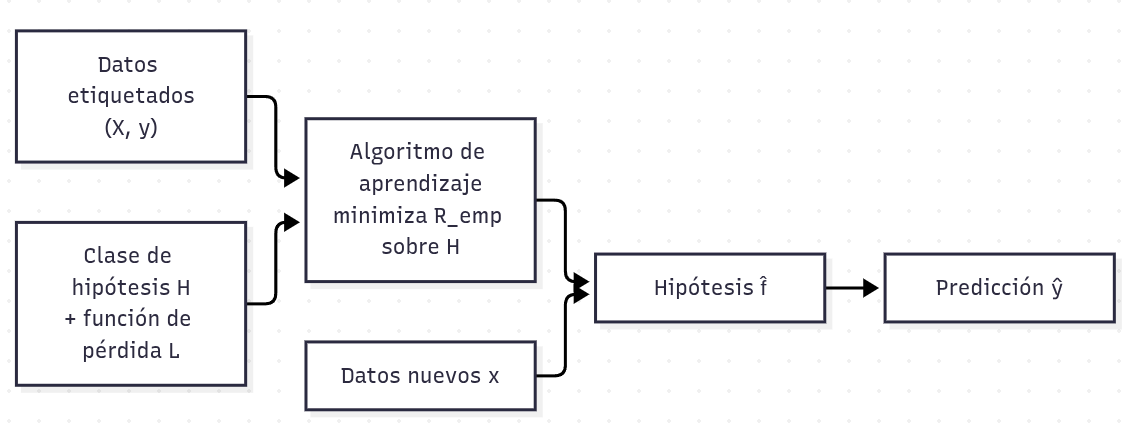

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
print("Entorno listo.")

In [ ]:
# ============================================================
# 1.2 Funciones de perdida: regresion (en el residuo) y clasificacion (en el margen)
# ============================================================
r = np.linspace(-3, 3, 400)                                   # residuo r = y - y_hat
cuadratica = r ** 2
absoluta = np.abs(r)
delta = 1.0
huber = np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta))

m = np.linspace(-3, 3, 400)                                   # margen m = y * s, con y en {-1, +1}
perdida_01 = (m <= 0).astype(float)
logistica = np.log(1 + np.exp(-m))                            # entropia cruzada expresada en el margen
bisagra = np.maximum(0, 1 - m)                                # hinge (la usan las SVM)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(r, cuadratica, label="Cuadrática  $r^2$", color="#2563eb", lw=2)
axes[0].plot(r, absoluta, label="Absoluta  $|r|$", color="#16a34a", lw=2)
axes[0].plot(r, huber, label="Huber ($\\delta=1$)", color="#f59e0b", lw=2, linestyle="--")
axes[0].set_ylim(0, 5)
axes[0].set_title("Regresión: pérdidas sobre el residuo", fontweight="bold")
axes[0].set_xlabel("Residuo $r = y - \\hat{y}$")
axes[0].set_ylabel("Pérdida $L$")
axes[0].legend()

axes[1].plot(m, perdida_01, label="0-1", color="#dc2626", lw=2)
axes[1].plot(m, logistica, label="Logística (entropía cruzada)", color="#2563eb", lw=2)
axes[1].plot(m, bisagra, label="Bisagra (hinge)", color="#16a34a", lw=2, linestyle="--")
axes[1].set_ylim(0, 4)
axes[1].set_title("Clasificación: pérdidas sobre el margen", fontweight="bold")
axes[1].set_xlabel("Margen $m = y \\cdot s$  (m > 0: acierto)")
axes[1].set_ylabel("Pérdida $L$")
axes[1].legend()
plt.tight_layout()
plt.show()

print("La cuadratica penaliza mucho los errores grandes (sensible a atipicos); la absoluta y Huber son mas robustas.")
print("La perdida 0-1 es plana y discontinua (sin gradiente util); la logistica y la bisagra son convexas y optimizables.")

---
## 2. El Riesgo Empírico es Optimista: Demostración 🔬

Para *medir* la brecha de generalización necesitamos conocer $P$, algo imposible con datos reales pero perfectamente posible en una **simulación**. Definimos un mundo sintético donde conocemos la verdad:

$$y = f(x) + \varepsilon, \qquad f(x) = \sin(2\pi x), \qquad x \sim U(0, 1), \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2), \;\; \sigma = 0.3.$$

El **error irreducible** (ruido) es $\sigma^2 = 0.09$: ningún modelo, ni siquiera el perfecto $f$, puede tener un error cuadrático medio esperado menor en datos nuevos.

La clase de hipótesis es $\mathcal{H}_d = \{\text{polinomios de grado} \le d\}$; **el grado $d$ es la complejidad del modelo**. Entrenamos con $n = 30$ puntos y aproximamos el riesgo verdadero $R(\hat{f})$ con una **población enorme** de 200.000 puntos nuevos (ley de los grandes números).

In [ ]:
# ============================================================
# 2. Riesgo empirico (entrenamiento) vs. riesgo verdadero (poblacion) segun la complejidad
# ============================================================
SIGMA = 0.3
f_verdadera = lambda x: np.sin(2 * np.pi * x)

def generar(n, rng, sigma=SIGMA):
    x = rng.uniform(0, 1, n)
    return x, f_verdadera(x) + rng.normal(0, sigma, n)

def ajustar_polinomio(x, y, grado):
    # Polynomial.fit reescala x a [-1, 1] internamente: evita la mala condicion de la matriz de Vandermonde
    return np.polynomial.Polynomial.fit(x, y, grado)

mse = lambda y, y_hat: np.mean((y - y_hat) ** 2)

rng = np.random.default_rng(SEED)
x_tr, y_tr = generar(30, rng)
x_pob, y_pob = generar(200_000, rng)                          # "poblacion": aproxima R(f)

grados = np.arange(0, 15)
riesgo_emp = [mse(y_tr, ajustar_polinomio(x_tr, y_tr, d)(x_tr)) for d in grados]
riesgo_ver = [mse(y_pob, ajustar_polinomio(x_tr, y_tr, d)(x_pob)) for d in grados]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grados, riesgo_emp, "o-", color="#2563eb", label="Riesgo empírico (entrenamiento, n=30)")
ax.plot(grados, riesgo_ver, "s-", color="#dc2626", label="Riesgo verdadero (población de 200.000)")
ax.axhline(SIGMA ** 2, color="black", linestyle="--", label=f"Error irreducible $\\sigma^2$ = {SIGMA**2:.2f}")
ax.set_yscale("log")
ax.set_xlabel("Complejidad del modelo (grado del polinomio)")
ax.set_ylabel("Error cuadrático medio (escala log)")
ax.set_title("El error de entrenamiento siempre baja; el verdadero se abre en abanico", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

d_mejor = grados[int(np.argmin(riesgo_ver))]
print(f"Grado con menor riesgo verdadero: {d_mejor}  (riesgo = {min(riesgo_ver):.3f}; piso teorico = {SIGMA**2:.3f})")
print(f"Con grado 14: riesgo empirico = {riesgo_emp[-1]:.4f}  vs  riesgo verdadero = {riesgo_ver[-1]:.2f}  -> brecha enorme")

---
**Lectura:** el riesgo empírico $R_{\text{emp}}$ es **no creciente** al aumentar el grado (los modelos más ricos contienen a los más simples, así que pueden ajustar al menos igual de bien los datos de entrenamiento). El riesgo verdadero, en cambio, tiene forma de "U": baja mientras el modelo gana capacidad de capturar la señal y **sube** cuando empieza a memorizar el ruido. Minimizar $R_{\text{emp}}$ *sin más* nos llevaría siempre al modelo más complejo, que es justo el peor.

## 3. Partición de los Datos: Entrenamiento, Validación y Prueba ✂️

Como el verdadero riesgo es inalcanzable, lo **estimamos** con datos que el modelo **no usó para ajustarse**. La práctica estándar divide el dataset en tres conjuntos con roles distintos:

| Conjunto | Proporción típica | Para qué sirve | ¿Se usa para ajustar parámetros? | ¿Se usa para elegir el modelo? |
|---|---|---|---|---|
| **Entrenamiento** (*train*) | 60–80 % | Ajustar los parámetros del modelo (coeficientes) | **Sí** | No |
| **Validación** (*validation*) | 10–20 % | Comparar modelos y elegir **hiperparámetros** (grado, $\alpha$, $C$, $k$…) | No | **Sí** |
| **Prueba** (*test*) | 10–20 % | Estimación **final e imparcial** de $R(\hat{f})$ | No | **No** |

> ⚠️ **Regla de oro:** el conjunto de prueba se usa **una sola vez**, al final. Cada vez que decides algo mirando su resultado, *se contamina* y deja de ser una estimación honesta (es una forma de fuga de información, como vimos en el [Módulo 00](../00%20-%20Introduccion%20al%20Machine%20Learning/03_Importancia_del_Preprocesamiento.ipynb)). Cuando los datos son pocos, la **validación cruzada** reemplaza al conjunto de validación fijo (ver el [cuaderno de Data Mining](../../Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/00_Fundamentos_del_Aprendizaje_Supervisado.ipynb)); aquí la usaremos en las curvas de la Sección 6.

Apliquemos el protocolo: elegimos el grado con el conjunto de **validación** y reportamos el error de **prueba** una única vez.

In [ ]:
# ============================================================
# 3. Protocolo train / validation / test (60 % / 20 % / 20 %)
# ============================================================
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(SEED)
x_all, y_all = generar(300, rng)

# Primero se aparta la prueba (20 %); luego, del resto, la validacion (25 % de 80 % = 20 % del total)
x_tmp, x_te, y_tmp, y_te = train_test_split(x_all, y_all, test_size=0.20, random_state=SEED)
x_tr, x_va, y_tr, y_va = train_test_split(x_tmp, y_tmp, test_size=0.25, random_state=SEED)
print(f"Tamaños -> train: {len(x_tr)} | validación: {len(x_va)} | prueba: {len(x_te)}")

filas = []
for d in range(0, 13):
    modelo = ajustar_polinomio(x_tr, y_tr, d)
    filas.append({"grado": d, "MSE_train": mse(y_tr, modelo(x_tr)), "MSE_validacion": mse(y_va, modelo(x_va))})
tabla = pd.DataFrame(filas).set_index("grado")
display(tabla.round(4))

d_elegido = int(tabla["MSE_validacion"].idxmin())                  # la VALIDACION decide el hiperparametro
final = ajustar_polinomio(np.r_[x_tr, x_va], np.r_[y_tr, y_va], d_elegido)   # se reajusta con train + validacion
print(f"\nGrado elegido con la validación: {d_elegido}")
print(f"MSE en PRUEBA (se mira una sola vez): {mse(y_te, final(x_te)):.4f}   (error irreducible = {SIGMA**2:.2f})")

---
##### 🛠️ Práctica 1: Elegir con la validación, no con el entrenamiento

La Sección 3 eligió el grado del polinomio con el conjunto de **validación**. ¿Qué habría pasado si lo hubiéramos elegido con el error de **entrenamiento**? Usa `tabla`, `x_tr`, `y_tr`, `d_elegido`, `generar()`, `ajustar_polinomio()` y `mse()`:

1. Guarda en `d_ent` el grado con menor `MSE_train` en `tabla`.
2. Genera una población nueva con `x_pob2, y_pob2 = generar(100_000, np.random.default_rng(2024))`: aproxima el riesgo verdadero $R(\hat{f})$ y deja intacto el conjunto de prueba.
3. Ajusta, **solo con el entrenamiento** (`x_tr`, `y_tr`), los modelos de grado `d_ent` y de grado `d_elegido`, y calcula el riesgo de cada uno sobre la población: `riesgo_ent` y `riesgo_val`.
4. Verifica con `assert` que `riesgo_val < riesgo_ent` y comenta: ¿por qué el error de entrenamiento siempre apunta al grado más alto?

In [ ]:
# Escribe tu código aquí

# d_ent = int(tabla["MSE_train"]. ...)
# x_pob2, y_pob2 = generar(100_000, np.random.default_rng(2024))
# modelo_ent = ajustar_polinomio(x_tr, y_tr, ...)
# modelo_val = ajustar_polinomio(x_tr, y_tr, ...)
# riesgo_ent = mse(y_pob2, modelo_ent(x_pob2))
# riesgo_val = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
d_ent = int(tabla["MSE_train"].idxmin())                         # el entrenamiento siempre premia el grado mas alto
x_pob2, y_pob2 = generar(100_000, np.random.default_rng(2024))    # poblacion nueva: aproxima R(f) sin tocar la prueba

modelo_ent = ajustar_polinomio(x_tr, y_tr, d_ent)                 # ambos modelos se ajustan SOLO con entrenamiento
modelo_val = ajustar_polinomio(x_tr, y_tr, d_elegido)
riesgo_ent = mse(y_pob2, modelo_ent(x_pob2))
riesgo_val = mse(y_pob2, modelo_val(x_pob2))

print(f"Grado elegido con entrenamiento: {d_ent}  -> riesgo verdadero = {riesgo_ent:.4f}")
print(f"Grado elegido con validacion:    {d_elegido}  -> riesgo verdadero = {riesgo_val:.4f}")
assert riesgo_val < riesgo_ent
print("El error de entrenamiento nunca sube al agregar complejidad (los modelos ricos contienen a los simples), asi que siempre elige el mas flexible; la validacion si detecta cuando empieza el sobreajuste.")
```
</details>

---


---
## 4. Sobreajuste y Subajuste 📉📈

- **Subajuste** (*underfitting*): el modelo es **demasiado simple** para capturar la estructura de los datos. Falla tanto en entrenamiento como en prueba. Es un problema de **sesgo alto**.
- **Sobreajuste** (*overfitting*): el modelo es **demasiado flexible** y aprende también el ruido de la muestra. Acierta en entrenamiento pero falla en datos nuevos. Es un problema de **varianza alta**.

Veamos tres modelos sobre la misma muestra pequeña ($n = 25$): uno rígido (grado 1), uno razonable (grado 3) y uno excesivamente flexible (grado 15, casi tantos parámetros como datos).

In [ ]:
# ============================================================
# 4. Subajuste vs. buen ajuste vs. sobreajuste (misma muestra, tres complejidades)
# ============================================================
rng = np.random.default_rng(7)
x_s, y_s = generar(25, rng)
x_pob, y_pob = generar(100_000, rng)
xs = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, d, nombre, col in zip(axes, [1, 3, 15], ["Subajuste", "Buen ajuste", "Sobreajuste"], ["#f59e0b", "#16a34a", "#dc2626"]):
    mod = ajustar_polinomio(x_s, y_s, d)
    ax.scatter(x_s, y_s, color="#475569", s=35, label="Datos de entrenamiento", zorder=3)
    ax.plot(xs, f_verdadera(xs), "k--", lw=1.5, label="Verdad $f(x)$")
    ax.plot(xs, mod(xs), color=col, lw=2.5, label=f"Modelo grado {d}")
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f"{nombre} (grado {d})\nMSE train = {mse(y_s, mod(x_s)):.3f} | MSE población = {mse(y_pob, mod(x_pob)):.3f}", fontweight="bold")
    ax.set_xlabel("$x$")
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("$y$")
plt.tight_layout()
plt.show()

---
## 5. Descomposición Sesgo–Varianza ⚖️

### 5.1 Derivación

Fijemos un punto $x_0$ y supongamos $y = f(x_0) + \varepsilon$, con $\mathbb{E}[\varepsilon] = 0$, $\operatorname{Var}(\varepsilon) = \sigma^2$ y $\varepsilon$ independiente del conjunto de entrenamiento $\mathcal{D}$. El predictor $\hat{f}_{\mathcal{D}}(x_0)$ es una **variable aleatoria** porque depende de la muestra $\mathcal{D}$ con la que se entrenó. Escribimos $\bar{f}(x_0) = \mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(x_0)]$ (la predicción *promedio* sobre todos los posibles conjuntos de entrenamiento). El error esperado de predicción con pérdida cuadrática es

$$\mathbb{E}\big[(y - \hat{f})^2\big] = \mathbb{E}\big[(f - \hat{f} + \varepsilon)^2\big] = \mathbb{E}\big[(f - \hat{f})^2\big] + 2\,\mathbb{E}\big[\varepsilon\,(f - \hat{f})\big] + \mathbb{E}[\varepsilon^2].$$

El término cruzado es cero (independencia y $\mathbb{E}[\varepsilon] = 0$) y $\mathbb{E}[\varepsilon^2] = \sigma^2$. Para el primer término sumamos y restamos $\bar{f}$:

$$\mathbb{E}\big[(f - \hat{f})^2\big] = \mathbb{E}\big[(f - \bar{f} + \bar{f} - \hat{f})^2\big] = (f - \bar{f})^2 + \mathbb{E}\big[(\hat{f} - \bar{f})^2\big],$$

porque el término cruzado $2(f - \bar{f})\,\mathbb{E}[\bar{f} - \hat{f}]$ se anula ($\mathbb{E}[\hat{f}] = \bar{f}$). Entonces:

$$\boxed{\;\mathbb{E}\big[(y - \hat{f}(x_0))^2\big] = \underbrace{\sigma^2}_{\text{ruido irreducible}} + \underbrace{\big(\bar{f}(x_0) - f(x_0)\big)^2}_{\text{Sesgo}^2} + \underbrace{\mathbb{E}\big[(\hat{f}(x_0) - \bar{f}(x_0))^2\big]}_{\text{Varianza}}\;}$$

| Componente | Qué mide | Cómo se reduce |
|---|---|---|
| **Ruido irreducible** $\sigma^2$ | Variabilidad intrínseca de $y$ dado $x$ | No se puede reducir (sí con *mejores variables*) |
| **Sesgo²** | Error sistemático: qué tan lejos está la predicción *promedio* de la verdad (clase $\mathcal{H}$ demasiado pobre) | Modelos más flexibles, más variables |
| **Varianza** | Cuánto cambia la predicción al cambiar la muestra de entrenamiento | Más datos, modelos más simples, regularización |

Al aumentar la complejidad, **el sesgo baja y la varianza sube**: de ahí el *trade-off* y el mínimo en forma de "U" del error de prueba.

### 5.2 Estimación numérica por Monte Carlo

En la práctica solo tenemos *una* muestra, así que $\bar{f}$ no se observa. En una simulación sí podemos **repetir el experimento**: generamos $M = 500$ conjuntos de entrenamiento independientes de tamaño $n = 50$, ajustamos el modelo en cada uno y evaluamos las predicciones sobre una rejilla fija $\{x_0^{(j)}\}$. Con ello estimamos

$$\widehat{\text{Sesgo}^2} = \frac{1}{G}\sum_j \big(\bar{f}(x_0^{(j)}) - f(x_0^{(j)})\big)^2, \qquad \widehat{\text{Var}} = \frac{1}{G}\sum_j \frac{1}{M}\sum_m \big(\hat{f}_m(x_0^{(j)}) - \bar{f}(x_0^{(j)})\big)^2,$$

y **verificamos la identidad** comparando $\sigma^2 + \text{Sesgo}^2 + \text{Var}$ con el error de prueba medido directamente (con etiquetas nuevas ruidosas).

In [ ]:
# ============================================================
# 5.2 Monte Carlo: sesgo^2, varianza y error esperado en funcion de la complejidad
# ============================================================
M, N_TRAIN = 500, 50
grados = np.arange(1, 11)
x_grid = np.linspace(0, 1, 200)
f_grid = f_verdadera(x_grid)
rng = np.random.default_rng(SEED)

# Predicciones de cada modelo en la rejilla: arreglo (grados, M, G)
preds = np.zeros((len(grados), M, len(x_grid)))
for m in range(M):
    x_m, y_m = generar(N_TRAIN, rng)                              # un conjunto de entrenamiento NUEVO en cada repeticion
    for i, d in enumerate(grados):
        preds[i, m] = ajustar_polinomio(x_m, y_m, d)(x_grid)

f_media = preds.mean(axis=1)                                       # f_barra(x0): prediccion promedio
sesgo2 = ((f_media - f_grid) ** 2).mean(axis=1)                    # sesgo^2 promediado sobre la rejilla
varianza = preds.var(axis=1).mean(axis=1)                          # varianza promediada sobre la rejilla
teorico = SIGMA ** 2 + sesgo2 + varianza                           # lado derecho de la identidad

# Medicion directa: etiquetas nuevas ruidosas y MSE de cada modelo
y_nuevas = f_grid + rng.normal(0, SIGMA, size=(M, len(x_grid)))    # (M, G): una realizacion de ruido por modelo
medido = np.array([((y_nuevas - preds[i]) ** 2).mean() for i in range(len(grados))])

tabla = pd.DataFrame({"grado": grados, "Sesgo2": sesgo2, "Varianza": varianza, "Ruido": SIGMA ** 2,
                      "Sesgo2+Var+Ruido": teorico, "Error medido": medido}).set_index("grado")
display(tabla.round(4))
print(f"Maxima discrepancia relativa entre la identidad y la medicion directa: {np.max(np.abs(teorico - medido) / medido):.1%}")
assert np.all(np.abs(teorico - medido) / medido < 0.10), "La descomposicion deberia coincidir con la medicion directa"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(grados, sesgo2, "o-", color="#2563eb", label="Sesgo²")
axes[0].plot(grados, varianza, "s-", color="#dc2626", label="Varianza")
axes[0].axhline(SIGMA ** 2, color="gray", linestyle=":", label="Ruido irreducible $\\sigma^2$")
axes[0].plot(grados, teorico, "k-", lw=2, label="Sesgo² + Varianza + $\\sigma^2$")
axes[0].plot(grados, medido, "x", color="#f59e0b", ms=10, mew=2, label="Error medido (Monte Carlo)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Complejidad (grado del polinomio)")
axes[0].set_ylabel("Error cuadrático (escala log)")
axes[0].set_title("Descomposición sesgo–varianza estimada por Monte Carlo", fontweight="bold")
axes[0].legend(fontsize=8)

# Panel derecho: 40 ajustes individuales para ver "la varianza" a simple vista
for d in [1, 9]:
    i = list(grados).index(d)
    for m in range(40):
        axes[1].plot(x_grid, preds[i, m], color="#2563eb" if d == 1 else "#dc2626", alpha=0.18, lw=1)
axes[1].plot(x_grid, f_grid, "k--", lw=2, label="Verdad")
axes[1].plot([], [], color="#2563eb", label="40 ajustes de grado 1 (sesgo alto, varianza baja)")
axes[1].plot([], [], color="#dc2626", label="40 ajustes de grado 9 (sesgo bajo, varianza alta)")
axes[1].set_ylim(-2.5, 2.5)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Predicción $\\hat{f}(x)$")
axes[1].set_title("La varianza vista: cómo se dispersan los ajustes", fontweight="bold")
axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

print(f"Grado con menor error esperado: {grados[np.argmin(teorico)]} (equilibrio sesgo-varianza)")

---
**Lectura de la simulación:**

- Con **grado 1** el sesgo² domina (la recta no puede imitar un seno completo) y los 40 ajustes son casi idénticos entre sí: baja varianza.
- Con grados altos el sesgo² casi desaparece, pero la **varianza se dispara**: cada muestra de $n = 50$ produce una curva muy distinta.
- El estimador de Sesgo² incluye un pequeño sesgo positivo del orden de $\text{Var}/M$ (la media de $M$ ajustes sigue siendo ruidosa); con $M = 500$ y $n = 50$ es despreciable salvo en grados muy altos.
- El error medido directamente coincide con $\sigma^2 + \text{Sesgo}^2 + \text{Var}$ (diferencias pequeñas atribuibles al error de Monte Carlo), confirmando la identidad derivada.

### 5.3 Regularización: una perilla continua de complejidad

Cambiar el grado es una forma *discreta* de controlar la complejidad. La **regularización** ofrece una perilla *continua*: se mantiene un modelo flexible, pero se **penaliza** la magnitud de los coeficientes. Por ejemplo, **Ridge** minimiza

$$\sum_{i=1}^{n} \big(y_i - f(\mathbf{x}_i)\big)^2 + \alpha \sum_j \beta_j^2 .$$

Un $\alpha$ mayor *encoge* los coeficientes: **aumenta algo el sesgo** pero **reduce mucho la varianza**. Repitamos el Monte Carlo con un polinomio de grado 12 y distintos valores de $\alpha$. (La regularización se estudia a fondo en [Data Science Programming — Módulo 07](../../Data%20Science%20programming/07%20-%20Regression/03_Regresion_Polinomial_y_Regularizacion.ipynb) y se introduce en el [cuaderno de Regresión Lineal](01_Regresion_Lineal.ipynb).)

In [ ]:
# ============================================================
# 5.3 Regularizacion como control de complejidad: mismo modelo (grado 12), distinto alpha
# ============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

alphas = np.logspace(-6, 1, 8)
M_R = 150
rng = np.random.default_rng(SEED)
preds_r = np.zeros((len(alphas), M_R, len(x_grid)))
for m in range(M_R):
    x_m, y_m = generar(N_TRAIN, rng)
    for i, a in enumerate(alphas):
        pipe = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(), Ridge(alpha=a))
        pipe.fit(x_m.reshape(-1, 1), y_m)
        preds_r[i, m] = pipe.predict(x_grid.reshape(-1, 1))

sesgo2_r = ((preds_r.mean(axis=1) - f_grid) ** 2).mean(axis=1)
var_r = preds_r.var(axis=1).mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, sesgo2_r, "o-", color="#2563eb", label="Sesgo²")
ax.plot(alphas, var_r, "s-", color="#dc2626", label="Varianza")
ax.plot(alphas, SIGMA ** 2 + sesgo2_r + var_r, "k-", lw=2, label="Error esperado = $\\sigma^2$ + Sesgo² + Var")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Fuerza de regularización $\\alpha$ (escala log)")
ax.set_ylabel("Error cuadrático (escala log)")
ax.set_title("Ridge sobre un polinomio de grado 12: $\\alpha$ intercambia varianza por sesgo", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print(f"alpha con menor error esperado: {alphas[np.argmin(SIGMA**2 + sesgo2_r + var_r)]:.1e}")

---
##### 🛠️ Práctica 2: Más datos reducen la varianza

En la Sección 5.2 estimamos sesgo² y varianza con $n = 50$ datos de entrenamiento. Comprueba qué pasa al pasar a $n = 500$ con un polinomio de grado 9 (es lo que sugiere la Autoevaluación 2). Usa `generar()`, `ajustar_polinomio()`, `x_grid`, `f_grid` y `SEED`:

1. Escribe una función `sesgo_var(n_train, grado, n_rep=200)` que cree `rng = np.random.default_rng(SEED)` y repita `n_rep` veces: generar un conjunto de entrenamiento de tamaño `n_train`, ajustar el polinomio y predecir sobre `x_grid`. Debe devolver `(sesgo2, varianza)` promediados sobre la rejilla (como en la Sección 5.2).
2. Calcula `sesgo2_50, var_50 = sesgo_var(50, 9)` y `sesgo2_500, var_500 = sesgo_var(500, 9)`.
3. Verifica con `assert` que `var_500 < var_50` y comenta: ¿qué ocurrió con el sesgo²? ¿Por qué?

In [ ]:
# Escribe tu código aquí

# def sesgo_var(n_train, grado, n_rep=200):
#     rng = np.random.default_rng(SEED)
#     preds = np.zeros((n_rep, len(x_grid)))
#     for m in range(n_rep):
#         x_m, y_m = generar(n_train, rng)
#         preds[m] = ajustar_polinomio(...)(x_grid)
#     sesgo2 = ((preds.mean(axis=0) - f_grid) ** 2).mean()
#     varianza = ...
#     return sesgo2, varianza
#
# sesgo2_50, var_50 = sesgo_var(50, 9)
# sesgo2_500, var_500 = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
def sesgo_var(n_train, grado, n_rep=200):
    rng = np.random.default_rng(SEED)
    preds = np.zeros((n_rep, len(x_grid)))
    for m in range(n_rep):
        x_m, y_m = generar(n_train, rng)                       # un conjunto de entrenamiento NUEVO en cada repeticion
        preds[m] = ajustar_polinomio(x_m, y_m, grado)(x_grid)
    sesgo2 = ((preds.mean(axis=0) - f_grid) ** 2).mean()       # (prediccion promedio - verdad)^2, promediado en la rejilla
    varianza = preds.var(axis=0).mean()                        # dispersion de las predicciones entre repeticiones
    return sesgo2, varianza

sesgo2_50, var_50 = sesgo_var(50, 9)
sesgo2_500, var_500 = sesgo_var(500, 9)
print(f"n = 50  -> sesgo2 = {sesgo2_50:.5f} | varianza = {var_50:.5f}")
print(f"n = 500 -> sesgo2 = {sesgo2_500:.5f} | varianza = {var_500:.5f}")
assert var_500 < var_50
print("La varianza cae casi en proporcion a 1/n; el sesgo2 casi no cambia porque depende de la clase de hipotesis (grado 9), no de cuantos datos haya.")
```
</details>

---


---
## 6. Curvas de Aprendizaje y Curvas de Validación 🩺

Son las dos herramientas de diagnóstico que revelan **de qué sufre** un modelo (Raschka, Cap. 6; Géron, Cap. 4):

| Curva | Eje X | Responde a la pregunta | Cómo se lee |
|---|---|---|---|
| **De aprendizaje** (*learning curve*) | Tamaño del conjunto de entrenamiento | ¿Me ayudaría tener **más datos**? | Si las curvas de *train* y *validación* convergen en un error **alto** → sesgo alto (más datos no ayudan; hace falta un modelo más rico). Si hay una **brecha grande** que se cierra lentamente → varianza alta (más datos o más regularización ayudan) |
| **De validación** (*validation curve*) | Un hiperparámetro de complejidad | ¿Qué complejidad es la adecuada? | El punto donde el error de validación es mínimo; a la izquierda hay subajuste y a la derecha sobreajuste |

Ambas usan **validación cruzada**, así que cada punto es un promedio con su dispersión.

In [ ]:
# ============================================================
# 6.1 Curvas de aprendizaje: sesgo alto (grado 1), buen ajuste (grado 4) y varianza alta (grado 10)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve, ShuffleSplit
from matplotlib.ticker import FuncFormatter

rng = np.random.default_rng(SEED)
x_d, y_d = generar(80, rng)                                        # muestra pequeña: aqui el sobreajuste si se manifiesta
X_d = x_d.reshape(-1, 1)

def modelo_poli(d):
    return make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), LinearRegression())

cv_ms = ShuffleSplit(n_splits=25, test_size=0.3, random_state=SEED)
tamanos = np.arange(20, 57, 4)                                       # tamaños absolutos del conjunto de entrenamiento

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, d, nombre in zip(axes, [1, 4, 10], ["Sesgo alto (grado 1)", "Buen ajuste (grado 4)", "Varianza alta (grado 10)"]):
    n_ent, tr, va = learning_curve(modelo_poli(d), X_d, y_d, train_sizes=tamanos, cv=cv_ms,
                                   scoring="neg_mean_squared_error")
    tr, va = -tr, -va
    ax.plot(n_ent, tr.mean(axis=1), "o-", color="#2563eb", label="Entrenamiento")
    ax.fill_between(n_ent, tr.mean(axis=1) - tr.std(axis=1), tr.mean(axis=1) + tr.std(axis=1), color="#2563eb", alpha=0.15)
    ax.plot(n_ent, va.mean(axis=1), "s-", color="#dc2626", label="Validación (CV)")
    ax.fill_between(n_ent, va.mean(axis=1) - va.std(axis=1), va.mean(axis=1) + va.std(axis=1), color="#dc2626", alpha=0.15)
    ax.axhline(SIGMA ** 2, color="black", linestyle="--", label="Ruido irreducible")
    ax.set_yscale("log")
    ax.set_ylim(0.03, 3)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_title(nombre, fontweight="bold")
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.legend(fontsize=8)
axes[0].set_ylabel("MSE (escala log)")
plt.suptitle("Curvas de aprendizaje: ¿más datos ayudarían?", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.2 Curva de validacion: el grado del polinomio como hiperparametro de complejidad
# ============================================================
from sklearn.model_selection import validation_curve

x_v, y_v = generar(40, np.random.default_rng(SEED))                  # muestra pequeña (n=40) para que se vea el sobreajuste
X_v = x_v.reshape(-1, 1)
grados_vc = np.arange(1, 14)
tr, va = validation_curve(make_pipeline(PolynomialFeatures(include_bias=False), StandardScaler(), LinearRegression()),
                          X_v, y_v, param_name="polynomialfeatures__degree", param_range=grados_vc,
                          cv=5, scoring="neg_mean_squared_error")
tr, va = -tr, -va
mejor = grados_vc[np.argmin(va.mean(axis=1))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grados_vc, tr.mean(axis=1), "o-", color="#2563eb", label="Entrenamiento")
ax.plot(grados_vc, va.mean(axis=1), "s-", color="#dc2626", label="Validación (CV, 5 particiones)")
ax.fill_between(grados_vc, va.mean(axis=1) - va.std(axis=1), va.mean(axis=1) + va.std(axis=1), color="#dc2626", alpha=0.15)
ax.axvline(mejor, color="#16a34a", linestyle="--", label=f"Mejor complejidad: grado {mejor}")
ax.axhline(SIGMA ** 2, color="black", linestyle=":", label="Ruido irreducible")
ax.axvspan(0.5, mejor - 0.5, color="#f59e0b", alpha=0.10)
ax.axvspan(mejor + 0.5, 13.5, color="#dc2626", alpha=0.06)
ax.text(0.03, 0.95, "Zona de subajuste", transform=ax.transAxes, color="#b45309", fontweight="bold", va="top")
ax.text(0.97, 0.95, "Zona de sobreajuste", transform=ax.transAxes, color="#b91c1c", fontweight="bold", va="top", ha="right")
ax.set_xlim(0.5, 13.5)
ax.set_yscale("log")
ax.set_yticks([0.03, 0.1, 0.3, 1]); ax.set_yticklabels(["0.03", "0.1", "0.3", "1"])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_ylim(0.025, 1.6)
ax.set_xlabel("Complejidad del modelo (grado del polinomio)")
ax.set_ylabel("MSE (escala log)")
ax.set_title("Curva de validación: el mínimo marca la complejidad adecuada", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Grado óptimo según la validación cruzada: {mejor} | MSE de validación = {va.mean(axis=1).min():.4f}")

---
### Receta de diagnóstico

| Síntoma | Diagnóstico | Remedios típicos |
|---|---|---|
| Error de *train* **alto** y error de validación **alto** (curvas juntas) | **Subajuste** / sesgo alto | Modelo más flexible, nuevas variables o transformaciones, **reducir** la regularización |
| Error de *train* **bajo** y error de validación **mucho mayor** (brecha) | **Sobreajuste** / varianza alta | Más datos, modelo más simple, **más regularización**, selección de variables |
| Ambos bajos y cercanos al ruido | Buen ajuste | Evaluar una sola vez en *test* |

## 7. No Free Lunch: No Existe el "Mejor" Algoritmo Universal 🍽️

Wolpert (1996) demostró, en lo que se conoce como **teorema *No Free Lunch* para aprendizaje supervisado**, que **promediado sobre *todos* los problemas posibles, ningún algoritmo supera a otro** (ni siquiera al azar) en error fuera de la muestra. Su versión análoga para optimización es de Wolpert y Macready (1997). La consecuencia práctica no es el pesimismo sino la **humildad**: todo modelo incorpora supuestos (un **sesgo inductivo**: linealidad, suavidad, vecindad…) y solo funciona bien cuando esos supuestos se parecen a la estructura del problema.

Un experimento (informal, no es el teorema) lo ilustra: cuatro modelos sobre cuatro problemas de clasificación con estructuras distintas. Ningún modelo gana en todos.

In [ ]:
# ============================================================
# 7. "No free lunch" (ilustracion empirica): el mejor modelo depende de la estructura del problema
# ============================================================
from sklearn.datasets import make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score

rng = np.random.default_rng(SEED)
n = 400
X_xor = rng.uniform(-1, 1, size=(n, 2))
y_xor = ((X_xor[:, 0] > 0) ^ (X_xor[:, 1] > 0)).astype(int)         # estructura tipo XOR (cuadrantes)

X_lin = rng.normal(size=(150, 20))                                   # frontera lineal en 20 dimensiones, con ruido
y_lin = (X_lin @ rng.normal(size=20) + rng.normal(0, 1.0, 150) > 0).astype(int)

problemas = {
    "Lineal (20 var.)": (X_lin, y_lin),
    "Lunas":         make_moons(n, noise=0.25, random_state=SEED),
    "Círculos":      make_circles(n, noise=0.08, factor=0.4, random_state=SEED),
    "XOR":           (X_xor, y_xor),
}
modelos = {
    "Regresión logística": make_pipeline(StandardScaler(), LogisticRegression()),
    "k-NN (k=15)":         make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    "Árbol (prof. 5)":     DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Naive Bayes":         GaussianNB(),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
res = pd.DataFrame({pn: {mn: cross_val_score(mod, Xp, yp, cv=cv).mean() for mn, mod in modelos.items()}
                    for pn, (Xp, yp) in problemas.items()})
display(res.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(res, annot=True, fmt=".2f", cmap="Blues", vmin=0.4, vmax=1.0, cbar_kws={"label": "Accuracy (CV, 5 particiones)"}, ax=ax)
ax.set_title("El mejor modelo cambia con la estructura del problema", fontweight="bold")
ax.set_xlabel("Problema")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()
print("Mejor modelo por problema:")
print(res.idxmax().to_string())

---
##### 🛠️ Práctica 3: Curva de validación para la fuerza de regularización

En la Sección 6.2 la curva de validación varió el **grado** del polinomio. Ahora la perilla de complejidad será la penalización $\alpha$ de Ridge sobre un polinomio de grado 12. Usa `X_v`, `y_v` (la muestra de $n = 40$), `alphas` (la rejilla de la Sección 5.3) y `validation_curve`:

1. Crea `pipe_r = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(), Ridge())`.
2. Calcula la curva con `param_name="ridge__alpha"`, `param_range=alphas`, `cv=5` y `scoring="neg_mean_squared_error"`. Pasa los resultados a positivos y guárdalos en `tr_r` y `va_r`.
3. Guarda en `alpha_mejor` el $\alpha$ con menor MSE medio de validación.
4. Verifica con `assert` que (a) ese mínimo es menor que el MSE de validación con el $\alpha$ más pequeño (casi sin regularizar) y (b) el MSE de **entrenamiento** crece al pasar del $\alpha$ más pequeño al más grande. Comenta: ¿a la izquierda de `alpha_mejor` hay subajuste o sobreajuste?

In [ ]:
# Escribe tu código aquí

# pipe_r = make_pipeline(PolynomialFeatures(...), StandardScaler(), Ridge())
# tr_r, va_r = validation_curve(pipe_r, X_v, y_v, param_name="ridge__alpha", ...)
# (recuerda cambiar el signo: el score es el MSE en negativo)
# alpha_mejor = alphas[np.argmin(...)]


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
pipe_r = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(), Ridge())
tr_r, va_r = validation_curve(pipe_r, X_v, y_v, param_name="ridge__alpha", param_range=alphas,
                              cv=5, scoring="neg_mean_squared_error")
tr_r, va_r = -tr_r, -va_r                                        # neg_mean_squared_error -> MSE positivo

alpha_mejor = alphas[np.argmin(va_r.mean(axis=1))]
print(pd.DataFrame({"alpha": alphas, "MSE_train": tr_r.mean(axis=1), "MSE_validacion": va_r.mean(axis=1)}).set_index("alpha").round(4))
print(f"\nalpha con menor MSE de validacion: {alpha_mejor:.1e}")

assert va_r.mean(axis=1).min() < va_r.mean(axis=1)[0]              # regularizar mejora frente a casi no regularizar
assert tr_r.mean(axis=1)[-1] > tr_r.mean(axis=1)[0]                # mas alpha = peor ajuste en entrenamiento
print("A la izquierda (alpha chico) el modelo es flexible: error de entrenamiento bajo y validacion alta = sobreajuste; a la derecha el modelo se rigidiza y ambos errores suben = subajuste.")
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Formulación** | Dado $\{(\mathbf{x}_i, y_i)\}$ i.i.d. de $P$, buscamos $\hat{f} \in \mathcal{H}$ que minimice la pérdida $L$ |
| **Riesgo** | $R(f)$ (verdadero, inalcanzable) vs. $R_{\text{emp}}(f)$ (calculable, **optimista**); ERM minimiza el segundo |
| **Regresión vs. clasificación** | Mismo marco; cambia el tipo de $y$ y la pérdida (cuadrática vs. 0-1 o sus sustitutas convexas) |
| **Partición** | *Train* ajusta parámetros, *validación* elige hiperparámetros, *test* se mira **una sola vez** |
| **Sub/sobreajuste** | Modelo muy simple (sesgo alto) vs. muy flexible (varianza alta) |
| **Sesgo–varianza** | $\mathbb{E}[(y-\hat{f})^2] = \sigma^2 + \text{Sesgo}^2 + \text{Var}$; la simulación Monte Carlo lo confirmó numéricamente |
| **Diagnóstico** | Curvas de aprendizaje (¿más datos?) y de validación (¿qué complejidad?) |
| **Regularización** | Perilla continua de complejidad: cambia varianza por un poco de sesgo |
| **No Free Lunch** | Sin supuestos sobre el problema no hay algoritmo universalmente mejor |

> 🎓 **Siguiente paso:** con este marco, el cuaderno [Regresión Lineal](01_Regresion_Lineal.ipynb) estudia el caso más simple de ERM con pérdida cuadrática y una clase de hipótesis lineal, y el de [Regresión Logística](02_Regresion_Logistica.ipynb) hace lo propio con la entropía cruzada.

---
### 🧠 Autoevaluación

1. Explica con tus palabras por qué $R_{\text{emp}}(\hat{f})$ es un estimador *optimista* de $R(\hat{f})$ y por qué la evaluación sobre el conjunto de entrenamiento no sirve para elegir entre modelos.
2. En la simulación de la Sección 5.2, ¿qué ocurriría con la curva de **varianza** si en lugar de $n = 50$ usáramos $n = 500$ datos de entrenamiento? ¿Y con la de **sesgo²**? Justifica y, si quieres, compruébalo modificando `N_TRAIN`.
3. Un colega entrena 200 combinaciones de hiperparámetros, elige la que mejor puntúa en el conjunto de **prueba** y reporta ese puntaje como el desempeño esperado en producción. ¿Qué está mal y cómo lo corregirías?
4. Observas una curva de aprendizaje donde el error de entrenamiento y el de validación se estabilizan **juntos** en un valor alto. ¿Conseguir 10 veces más datos resolvería el problema? ¿Qué cambiarías?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>